In [1]:
# ============================================================
#  SAR Wind Field Estimation — Data Pipeline
#  Ocean wind retrieval from Sentinel-1 SAR
#  Tamil Nadu / Gujarat coastal waters, India
# ============================================================

# run once at the start of a session, restart if prompted
# !pip install -q earthengine-api albumentations

import ee
import math
import numpy as np
import torch
import requests
from io import BytesIO
from torch.utils.data import Dataset
import albumentations as A
from google.colab import drive
import os, pickle, time

print("imports ok")


# this opens a browser tab — paste the verification code back here
# only needed once per session, GEE caches the credential
ee.Authenticate()
ee.Initialize(project='sar-wind-project')   # swap to your actual GEE project id
print("Earth Engine ready")


# Colab VMs reset every ~12 h so everything lives on Drive
# on the next session you just reload the pickle without hitting GEE again
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/sar_wind_data'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"saving to {SAVE_DIR}")


def is_mostly_ocean(aoi, min_water_fraction=0.85):
    # uses the JRC permanent water layer to skip patches where most pixels
    # are land — backscatter over buildings and vegetation has nothing to do
    # with open-ocean surface roughness, so land-heavy patches would just
    # add noise to the labels and confuse the model
    try:
        water      = ee.Image('JRC/GSW1_4/GlobalSurfaceWater').select('occurrence')
        ocean_mask = water.gt(50)
        total_px   = ocean_mask.reduceRegion(
            ee.Reducer.count(), aoi, 1000).get('occurrence').getInfo()
        water_px   = ocean_mask.selfMask().reduceRegion(
            ee.Reducer.count(), aoi, 1000).get('occurrence').getInfo()
        if total_px is None or total_px == 0:
            return False
        return (water_px / total_px) >= min_water_fraction
    except Exception:
        # if the water check itself errors (timeout, quota) just let the patch
        # through — a few land-contaminated samples won't break training
        return True


def fetch_single_sample(center_lon, center_lat, date_start, date_end,
                         buffer_km=15, target_px=256, scale_m=100):
    # pulls one Sentinel-1 scene + collocated ERA-5 wind label for the given
    # point and date window.
    #
    # sar_patch  : shape (2, 256, 256), channels are VV and VH (dB scale, z-scored)
    # wind_label : [speed m/s, direction deg (met. convention: FROM which wind blows)]
    #
    # ERA-5 spatial resolution is ~25 km while the SAR patches are at 100 m,
    # so each label is effectively an area-averaged wind over the patch footprint.
    # the model therefore learns the prevailing background wind rather than
    # individual gusts or sub-km variability — that's intentional for this
    # large-scale mapping application.

    aoi    = ee.Geometry.Point([center_lon, center_lat]).buffer(buffer_km * 1000)
    bounds = aoi.bounds()

    if not is_mostly_ocean(aoi):
        return None, None

    s1_col = (
        ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(aoi)
        .filterDate(date_start, date_end)
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
        .filter(ee.Filter.eq('instrumentMode', 'IW'))
    )

    if s1_col.size().getInfo() == 0:
        return None, None

    sar_img      = s1_col.first().select(['VV', 'VH'])
    capture_time = sar_img.get('system:time_start')

    try:
        dl_url    = sar_img.getDownloadURL({
            'region': bounds,
            'scale' : scale_m,
            'format': 'NPY'
        })
        resp      = requests.get(dl_url, timeout=60)
        raw_arr   = np.load(BytesIO(resp.content))
        sar_patch = np.stack([raw_arr['VV'], raw_arr['VH']], axis=0).astype(np.float32)
        sar_patch = np.nan_to_num(sar_patch)   # land / no-data pixels → 0

        # per-channel z-score so VV (typically −5 to −20 dB) and
        # VH (typically −10 to −30 dB) end up on a similar scale
        for ch in range(sar_patch.shape[0]):
            mu            = sar_patch[ch].mean()
            sigma         = sar_patch[ch].std() + 1e-6
            sar_patch[ch] = (sar_patch[ch] - mu) / sigma

        h, w = sar_patch.shape[1], sar_patch.shape[2]
        if h < target_px or w < target_px:
            return None, None

        cy   = h // 2
        cx   = w // 2
        half = target_px // 2
        sar_patch = sar_patch[:, cy - half : cy + half,
                                  cx - half : cx + half]

    except Exception:
        return None, None

    era5_col = (
        ee.ImageCollection('ECMWF/ERA5/HOURLY')
        .filterBounds(aoi)
        .filterDate(
            ee.Date(capture_time).advance(-1, 'hour'),
            ee.Date(capture_time).advance( 1, 'hour')
        )
    )

    if era5_col.size().getInfo() == 0:
        return None, None

    era5_img = era5_col.first()

    try:
        u_wind = (era5_img.select('u_component_of_wind_10m')
                          .reduceRegion(ee.Reducer.mean(), aoi, 10000)
                          .get('u_component_of_wind_10m').getInfo())
        v_wind = (era5_img.select('v_component_of_wind_10m')
                          .reduceRegion(ee.Reducer.mean(), aoi, 10000)
                          .get('v_component_of_wind_10m').getInfo())

        if u_wind is None or v_wind is None:
            return None, None

        wind_speed = math.sqrt(u_wind**2 + v_wind**2)

        # meteorological convention: direction FROM which the wind blows
        # 0° = from north, 90° = from east, clockwise positive
        # atan2(u, v) with u=eastward, v=northward gives the bearing to the
        # wind source; adding 180° flips it to FROM direction
        wind_dir = (math.atan2(u_wind, v_wind) * 180 / math.pi + 180) % 360

    except Exception:
        return None, None

    return sar_patch, np.array([wind_speed, wind_dir], dtype=np.float32)


# splitting by time rather than random shuffle — patches that are spatially
# close and from the same orbit share almost identical wind conditions,
# so a random split would give the model an easy shortcut during validation.
# using 2024 for training and a completely different year (2023) for final
# test evaluation avoids this entirely.

TRAIN_WINDOWS = [
    ('2024-01-01', '2024-01-28'),   # NE monsoon tail / dry season
    ('2024-03-01', '2024-03-28'),   # pre-summer transition
    ('2024-05-01', '2024-05-28'),   # SW monsoon onset
    ('2024-08-01', '2024-08-28'),   # peak SW monsoon, strongest winds
    ('2024-10-01', '2024-10-28'),   # retreating monsoon
]

TEST_WINDOWS = [
    ('2023-01-01', '2023-01-28'),
    ('2023-06-01', '2023-06-28'),
    ('2023-10-01', '2023-10-28'),
]


CHECKPOINT_FILE = os.path.join(SAVE_DIR, 'raw_patches.pkl')

grid_lats = np.linspace(8.5, 13.5, 20)
grid_lons = np.linspace(79.5, 80.7, 15)

if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE, 'rb') as fh:
        ckpt_data = pickle.load(fh)
    train_patches  = ckpt_data.get('train_patches', [])
    train_labels   = ckpt_data.get('train_labels',  [])
    test_patches   = ckpt_data.get('test_patches',  [])
    test_labels    = ckpt_data.get('test_labels',   [])
    done_keys      = set(ckpt_data.get('done_keys', []))
    print(f"resumed — train: {len(train_patches)}  test: {len(test_patches)}")
else:
    train_patches, train_labels = [], []
    test_patches,  test_labels  = [], []
    done_keys = set()

def _run_fetch_loop(windows, patch_list, label_list, split_tag):
    total     = len(grid_lats) * len(grid_lons) * len(windows)
    attempted = 0
    for lat in grid_lats:
        for lon in grid_lons:
            for t_start, t_end in windows:
                job_key    = f"{split_tag}_{lat:.2f}_{lon:.2f}_{t_start}"
                attempted += 1
                if job_key in done_keys:
                    continue
                patch, lbl = fetch_single_sample(lon, lat, t_start, t_end)
                done_keys.add(job_key)
                if patch is not None and patch.shape == (2, 256, 256):
                    patch_list.append(patch)
                    label_list.append(lbl)
                if attempted % 30 == 0:
                    _save_checkpoint()
                    print(f"  [{split_tag}] {attempted}/{total}  "
                          f"train: {len(train_patches)}  test: {len(test_patches)}")
                time.sleep(0.3)

def _save_checkpoint():
    with open(CHECKPOINT_FILE, 'wb') as fh:
        pickle.dump({'train_patches': train_patches,
                     'train_labels' : train_labels,
                     'test_patches' : test_patches,
                     'test_labels'  : test_labels,
                     'done_keys'    : done_keys}, fh)

print("fetching train data (2024 windows)...")
_run_fetch_loop(TRAIN_WINDOWS, train_patches, train_labels, 'train')

print("fetching test data (2023 windows)...")
_run_fetch_loop(TEST_WINDOWS,  test_patches,  test_labels,  'test')

_save_checkpoint()
print(f"done — train: {len(train_patches)}  test: {len(test_patches)}")


train_sar_t  = torch.tensor(np.array(train_patches), dtype=torch.float32)
train_lbl_t  = torch.tensor(np.array(train_labels),  dtype=torch.float32)
test_sar_t   = torch.tensor(np.array(test_patches),  dtype=torch.float32)
test_lbl_t   = torch.tensor(np.array(test_labels),   dtype=torch.float32)

torch.save({
    'train_sar'   : train_sar_t,
    'train_labels': train_lbl_t,
    'test_sar'    : test_sar_t,
    'test_labels' : test_lbl_t,
}, os.path.join(SAVE_DIR, 'dataset_tensors.pt'))

print(f"train SAR : {train_sar_t.shape}   labels: {train_lbl_t.shape}")
print(f"test  SAR : {test_sar_t.shape}    labels: {test_lbl_t.shape}")


class SARWindDataset(Dataset):
    # inputs  : (N, 2, 256, 256) — VV and VH channels
    # targets : [norm_speed, sin(dir), cos(dir)]
    #
    # direction is encoded as (sin, cos) rather than raw degrees to avoid the
    # discontinuity at 0°/360° — without this encoding 359° and 1° are 358 units
    # apart in label space but physically 2° apart, which produces huge loss
    # spikes every time the wind is roughly from the north.
    #
    # speed is divided by 30 to bring it into roughly [0, 1] for typical
    # coastal monsoon winds; a label of 1.0 means ~30 m/s (hurricane force),
    # which is well above what we expect in this region.

    def __init__(self, sar_patches, wind_labels, augment=False):
        self.sar_data  = sar_patches
        self.wind_data = wind_labels
        self.augment   = augment

        # horizontal flip is valid because wind patterns can mirror left/right
        # without any contradiction in the label — the direction label stays the
        # same since ERA-5 gives an area mean, not a direction relative to the
        # image frame.
        # gaussian noise mimics the SAR speckle variation you get between
        # different acquisition geometries and sea states.
        # rotation is deliberately excluded: the SAR range/azimuth axes are
        # tied to the satellite heading, so rotating the image would make the
        # direction label wrong.
        self.aug_pipeline = A.Compose([
            A.HorizontalFlip(p=0.5),
            A.GaussNoise(std_range=(0.03, 0.07), p=0.3),
        ])

    def __len__(self):
        return len(self.sar_data)

    def __getitem__(self, idx):
        # albumentations wants HWC, pytorch wants CHW — convert back and forth
        img_hwc = self.sar_data[idx].numpy().transpose(1, 2, 0)

        if self.augment:
            img_hwc = self.aug_pipeline(image=img_hwc)['image']

        img_chw    = torch.tensor(img_hwc.transpose(2, 0, 1), dtype=torch.float32)
        spd, dirn  = float(self.wind_data[idx][0]), float(self.wind_data[idx][1])

        target_vec = torch.tensor([
            spd / 30.0,
            math.sin(math.radians(dirn)),
            math.cos(math.radians(dirn)),
        ], dtype=torch.float32)

        return img_chw, target_vec

print("SARWindDataset ready")

imports ok
Earth Engine ready
Mounted at /content/drive
saving to /content/drive/MyDrive/sar_wind_data
resumed — train: 515  test: 309
fetching train data (2024 windows)...
fetching test data (2023 windows)...
done — train: 515  test: 309
train SAR : torch.Size([515, 2, 256, 256])   labels: torch.Size([515, 2])
test  SAR : torch.Size([309, 2, 256, 256])    labels: torch.Size([309, 2])
SARWindDataset ready


train  SAR: torch.Size([515, 2, 256, 256])  labels: torch.Size([515, 2])
test   SAR: torch.Size([309, 2, 256, 256])   labels: torch.Size([309, 2])
batches — train: 28  val: 5  test: 20
device: cuda
GPU: Tesla T4
AMP: on
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 123MB/s]



training for 80 epochs (15 warmup)

 Epoch      Train        Val   Spd MAE   Spd RMSE   Dir MAE   Dir RMSE  Note
------------------------------------------------------------------------------------------
     1   1.270383   1.145361     2.573      3.220     51.20      60.21  ✓ saved
     5   0.999554   1.037363     1.971      2.474     45.91      59.49  
    10   0.861355   0.817497     1.729      2.154     37.53      55.77  ✓ saved
    15   0.850510   0.914038     1.682      2.053     41.39      58.17  

  epoch 16: backbone unfrozen, cosine LR schedule starts

    20   1.082754   0.948023     2.457      3.077     44.15      55.53  
    25   1.025975   0.990386     1.854      2.236     44.36      58.15  
    30   0.792272   0.816688     1.782      2.094     38.76      53.72  ✓ saved
    35   0.678274   0.805765     1.743      2.117     36.25      54.46  
    40   0.608398   0.983572     1.672      2.045     42.36      63.19  
    45   0.511778   0.599396     1.614      1.969     29.7

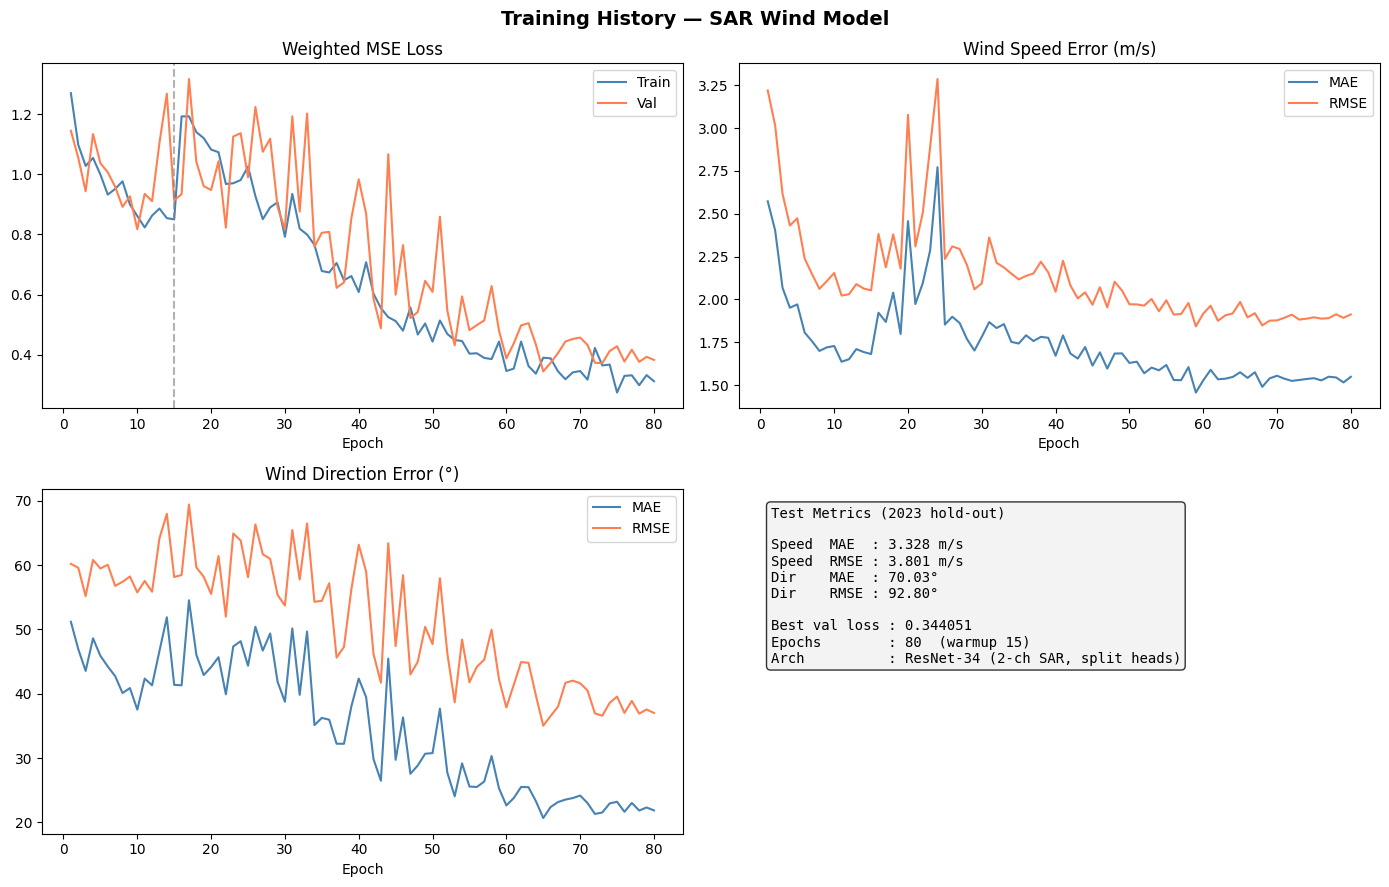

curves saved → /content/drive/MyDrive/sar_wind_data/training_curves.png


In [2]:
# ============================================================
#  SAR Wind Field Estimation — Model Training
#  Run after the data pipeline cell.
# ============================================================

from sklearn.model_selection import train_test_split
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import models
import os, math
import numpy as np
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


SAVE_DIR    = '/content/drive/MyDrive/sar_wind_data'
TENSOR_FILE = os.path.join(SAVE_DIR, 'dataset_tensors.pt')
MODEL_FILE  = os.path.join(SAVE_DIR, 'best_wind_model.pth')

saved       = torch.load(TENSOR_FILE)
train_sar_t = saved['train_sar']
train_lbl_t = saved['train_labels']
test_sar_t  = saved['test_sar']
test_lbl_t  = saved['test_labels']

print(f"train  SAR: {train_sar_t.shape}  labels: {train_lbl_t.shape}")
print(f"test   SAR: {test_sar_t.shape}   labels: {test_lbl_t.shape}")

if len(train_sar_t) < 500:
    print(f"warning: only {len(train_sar_t)} training samples — "
          f"consider expanding the grid or date windows")


# 15% of the 2024 data aside for in-training validation; the 2023 test
# split stays completely untouched until the very last eval block
sar_train, sar_val, lbl_train, lbl_val = train_test_split(
    train_sar_t, train_lbl_t, test_size=0.15, random_state=42
)

BATCH_SIZE = 16   # comfortably fits on a Colab T4

train_loader = DataLoader(
    SARWindDataset(sar_train, lbl_train, augment=True),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    SARWindDataset(sar_val, lbl_val, augment=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)
test_loader = DataLoader(
    SARWindDataset(test_sar_t, test_lbl_t, augment=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

print(f"batches — train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}")


class WindResNet(nn.Module):
    # ResNet-34 adapted for two-channel SAR input (VV and VH)
    #
    # two heads branch off a shared 256-dim bottleneck: one for wind speed
    # and one for direction. the direction head outputs a 2-vector which gets
    # L2-normalized in forward() so it always lies on the unit circle — this
    # hard-wires the constraint sin²+cos²=1 rather than asking the loss to
    # enforce it indirectly, which frees up gradient budget for actually
    # learning direction from the texture patterns.
    #
    # for the 2-channel conv adaptation: rather than averaging all three
    # pretrained RGB channels together (which would make VV and VH start
    # with identical filters), we take channels 0 and 1 of the pretrained
    # weights and rescale by 3/2 so the expected signal magnitude going
    # into the first conv is the same as with three channels. VV gets the
    # R-channel filters and VH gets the G-channel filters — their sensitivity
    # profiles are loosely analogous to the polarization contrast.

    def __init__(self, dropout_rate=0.3):
        super().__init__()
        backbone = models.resnet34(weights=models.ResNet34_Weights.DEFAULT)

        old_w   = backbone.conv1.weight.data            # (64, 3, 7, 7)
        new_w   = old_w[:, :2, :, :].clone() * (3/2)   # (64, 2, 7, 7) — rescaled
        backbone.conv1 = nn.Conv2d(2, 64, 7, stride=2, padding=3, bias=False)
        backbone.conv1.weight.data = new_w

        # keep everything up to (but not including) the original FC layer
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        feat_dim      = backbone.fc.in_features   # 512 for ResNet-34

        # shared compression layer with BN so both heads see normalised features
        self.shared = nn.Sequential(
            nn.Linear(feat_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
        )

        # speed head: final ReLU because wind speed can't be negative
        self.speed_head = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 1),
            nn.ReLU(),
        )

        # direction head: no activation — the forward() normalises the output
        # to the unit circle, so the raw magnitudes don't matter
        self.dir_head = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        feat    = self.features(x).flatten(1)               # (B, 512)
        shared  = self.shared(feat)                         # (B, 256)
        speed   = self.speed_head(shared)                   # (B, 1)
        dir_vec = F.normalize(self.dir_head(shared), dim=1) # (B, 2) — unit circle
        return torch.cat([speed, dir_vec], dim=1)           # (B, 3)

    def freeze_backbone(self):
        for param in self.features.parameters():
            param.requires_grad = False

    def unfreeze_backbone(self):
        for param in self.features.parameters():
            param.requires_grad = True


class WindLoss(nn.Module):
    # weighted MSE: speed and direction get separate terms so we can turn up the
    # pressure on direction without changing the speed gradient.
    #
    # direction MAE is typically much worse than speed MAE early in training —
    # the surface roughness texture that encodes direction is subtler than the
    # overall backscatter level that encodes speed, so direction gets a larger
    # coefficient to compensate for the weaker natural gradient signal.
    # dir_weight=2.5 was chosen empirically; tune it down if speed diverges.

    def __init__(self, dir_weight=2.5):
        super().__init__()
        self.dir_weight = dir_weight

    def forward(self, pred, target):
        speed_loss = F.mse_loss(pred[:, 0], target[:, 0])
        dir_loss   = F.mse_loss(pred[:, 1:], target[:, 1:])
        return speed_loss + self.dir_weight * dir_loss


def compute_wind_metrics(preds, targets):
    # MAE and RMSE for speed (m/s) and direction (deg)
    # direction difference uses the shortest arc so 359° vs 1° → 2°, not 358°
    p = preds.detach().cpu().numpy()
    t = targets.detach().cpu().numpy()

    pred_spd = p[:, 0] * 30.0
    true_spd = t[:, 0] * 30.0
    spd_diff = pred_spd - true_spd
    spd_mae  = float(np.mean(np.abs(spd_diff)))
    spd_rmse = float(np.sqrt(np.mean(spd_diff**2)))

    pred_dir = np.degrees(np.arctan2(p[:, 1], p[:, 2])) % 360
    true_dir = np.degrees(np.arctan2(t[:, 1], t[:, 2])) % 360
    dir_diff = np.abs(pred_dir - true_dir)
    dir_diff = np.where(dir_diff > 180, 360 - dir_diff, dir_diff)
    dir_mae  = float(np.mean(dir_diff))
    dir_rmse = float(np.sqrt(np.mean(dir_diff**2)))

    return {
        'speed_mae_m_s' : spd_mae,
        'speed_rmse_m_s': spd_rmse,
        'dir_mae_deg'   : dir_mae,
        'dir_rmse_deg'  : dir_rmse,
    }


device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

use_amp = (device.type == 'cuda')
scaler  = torch.amp.GradScaler(enabled=use_amp)
print(f"AMP: {'on' if use_amp else 'off (CPU)'}")

model   = WindResNet(dropout_rate=0.3).to(device)
loss_fn = WindLoss(dir_weight=2.5)

model.freeze_backbone()

# warmup phase trains only the two heads while the pretrained backbone is frozen —
# this lets the heads converge from random init before we start nudging the
# backbone features, which avoids overwriting useful edge detectors early on.
# after warmup we unfreeze everything and switch to cosine annealing with a
# lower LR so the backbone moves slowly and doesn't destroy what it learned.
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-4
)
scheduler = None

TOTAL_EPOCHS  = 80
WARMUP_EPOCHS = 15

best_val_loss = float('inf')
history = {
    'train_loss' : [],
    'val_loss'   : [],
    'speed_mae'  : [],
    'speed_rmse' : [],
    'dir_mae'    : [],
    'dir_rmse'   : [],
}

print(f"\ntraining for {TOTAL_EPOCHS} epochs ({WARMUP_EPOCHS} warmup)\n")
print(f"{'Epoch':>6}  {'Train':>9}  {'Val':>9}  "
      f"{'Spd MAE':>8}  {'Spd RMSE':>9}  {'Dir MAE':>8}  {'Dir RMSE':>9}  Note")
print("-" * 90)

for epoch in range(1, TOTAL_EPOCHS + 1):

    if epoch == WARMUP_EPOCHS + 1:
        print(f"\n  epoch {epoch}: backbone unfrozen, cosine LR schedule starts\n")
        model.unfreeze_backbone()
        optimizer = optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=(TOTAL_EPOCHS - WARMUP_EPOCHS), eta_min=1e-6
        )

    model.train()
    running_train_loss = 0.0

    for batch_imgs, batch_lbls in train_loader:
        batch_imgs = batch_imgs.to(device, non_blocking=True)
        batch_lbls = batch_lbls.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=use_amp):
            preds = model(batch_imgs)
            loss  = loss_fn(preds, batch_lbls)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        running_train_loss += loss.item()

    if scheduler is not None:
        scheduler.step()

    avg_train_loss = running_train_loss / len(train_loader)

    model.eval()
    running_val_loss     = 0.0
    all_preds, all_tgts  = [], []

    with torch.no_grad():
        for batch_imgs, batch_lbls in val_loader:
            batch_imgs = batch_imgs.to(device, non_blocking=True)
            batch_lbls = batch_lbls.to(device, non_blocking=True)
            with torch.amp.autocast('cuda', enabled=use_amp):
                preds = model(batch_imgs)
                running_val_loss += loss_fn(preds, batch_lbls).item()
            all_preds.append(preds)
            all_tgts.append(batch_lbls)

    avg_val_loss = running_val_loss / len(val_loader)
    metrics      = compute_wind_metrics(torch.cat(all_preds), torch.cat(all_tgts))

    history['train_loss'].append(avg_train_loss)
    history['val_loss'  ].append(avg_val_loss)
    history['speed_mae' ].append(metrics['speed_mae_m_s'])
    history['speed_rmse'].append(metrics['speed_rmse_m_s'])
    history['dir_mae'   ].append(metrics['dir_mae_deg'])
    history['dir_rmse'  ].append(metrics['dir_rmse_deg'])

    note = ''
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'optim_state': optimizer.state_dict(),
            'val_loss'   : best_val_loss,
            'metrics'    : metrics,
        }, MODEL_FILE)
        note = '✓ saved'

    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6}  {avg_train_loss:>9.6f}  {avg_val_loss:>9.6f}  "
              f"{metrics['speed_mae_m_s']:>8.3f}  {metrics['speed_rmse_m_s']:>9.3f}  "
              f"{metrics['dir_mae_deg']:>8.2f}  {metrics['dir_rmse_deg']:>9.2f}  {note}")

print(f"\ndone — best val loss: {best_val_loss:.6f}")
print(f"checkpoint → {MODEL_FILE}")


# test set runs exactly once, after training is fully complete —
# don't use these numbers to make any further tuning decisions or the
# 2023 hold-out stops being a clean unseen evaluation
print("\n──── test set evaluation (2023 held-out) ────")
ckpt = torch.load(MODEL_FILE, map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()

test_preds, test_tgts = [], []
with torch.no_grad():
    for batch_imgs, batch_lbls in test_loader:
        batch_imgs = batch_imgs.to(device, non_blocking=True)
        batch_lbls = batch_lbls.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=use_amp):
            test_preds.append(model(batch_imgs))
        test_tgts.append(batch_lbls)

test_metrics = compute_wind_metrics(torch.cat(test_preds), torch.cat(test_tgts))
print(f"  speed MAE  : {test_metrics['speed_mae_m_s']:.3f} m/s")
print(f"  speed RMSE : {test_metrics['speed_rmse_m_s']:.3f} m/s")
print(f"  dir   MAE  : {test_metrics['dir_mae_deg']:.2f}°")
print(f"  dir   RMSE : {test_metrics['dir_rmse_deg']:.2f}°")


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Training History — SAR Wind Model', fontsize=14, fontweight='bold')

epochs_x = range(1, len(history['train_loss']) + 1)

ax = axes[0, 0]
ax.plot(epochs_x, history['train_loss'], label='Train', color='steelblue')
ax.plot(epochs_x, history['val_loss'],   label='Val',   color='coral')
ax.set_title('Weighted MSE Loss');  ax.set_xlabel('Epoch');  ax.legend()
ax.axvline(WARMUP_EPOCHS, color='grey', linestyle='--', alpha=0.6, label='unfreeze')

ax = axes[0, 1]
ax.plot(epochs_x, history['speed_mae'],  label='MAE',  color='steelblue')
ax.plot(epochs_x, history['speed_rmse'], label='RMSE', color='coral')
ax.set_title('Wind Speed Error (m/s)');  ax.set_xlabel('Epoch');  ax.legend()

ax = axes[1, 0]
ax.plot(epochs_x, history['dir_mae'],  label='MAE',  color='steelblue')
ax.plot(epochs_x, history['dir_rmse'], label='RMSE', color='coral')
ax.set_title('Wind Direction Error (°)');  ax.set_xlabel('Epoch');  ax.legend()

ax = axes[1, 1]
ax.axis('off')
summary_txt = (
    f"Test Metrics (2023 hold-out)\n\n"
    f"Speed  MAE  : {test_metrics['speed_mae_m_s']:.3f} m/s\n"
    f"Speed  RMSE : {test_metrics['speed_rmse_m_s']:.3f} m/s\n"
    f"Dir    MAE  : {test_metrics['dir_mae_deg']:.2f}°\n"
    f"Dir    RMSE : {test_metrics['dir_rmse_deg']:.2f}°\n\n"
    f"Best val loss : {best_val_loss:.6f}\n"
    f"Epochs        : {TOTAL_EPOCHS}  (warmup {WARMUP_EPOCHS})\n"
    f"Arch          : ResNet-34 (2-ch SAR, split heads)"
)
ax.text(0.05, 0.95, summary_txt, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))

plt.tight_layout()
plot_path = os.path.join(SAVE_DIR, 'training_curves.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"curves saved → {plot_path}")

model loaded — epoch 65, val_loss 0.344051

  public URL : https://8000-gpu-t4-s-kkb-ass1c1-ff08v0dfbjw4-c.asia-southeast1-1.prod.colab.dev
  swagger UI : https://8000-gpu-t4-s-kkb-ass1c1-ff08v0dfbjw4-c.asia-southeast1-1.prod.colab.dev/docs
  health     : https://8000-gpu-t4-s-kkb-ass1c1-ff08v0dfbjw4-c.asia-southeast1-1.prod.colab.dev/health

  from inside the notebook use localhost, not the public URL:
  r = requests.get('http://localhost:8000/wind_field', params={
        'min_lon':79.7, 'min_lat':10.5, 'max_lon':80.5, 'max_lat':13.0,
        'date_start':'2024-08-01', 'date_end':'2024-08-28'})
  print(r.json())
health check: {'status': 'running', 'model_epoch': 65, 'device': 'cuda'}
downloading mosaic [79.7,10.5] → [80.5,13.0]  (40×40 = 1600 points)...
running inference row by row...
done — 1008 wind vectors


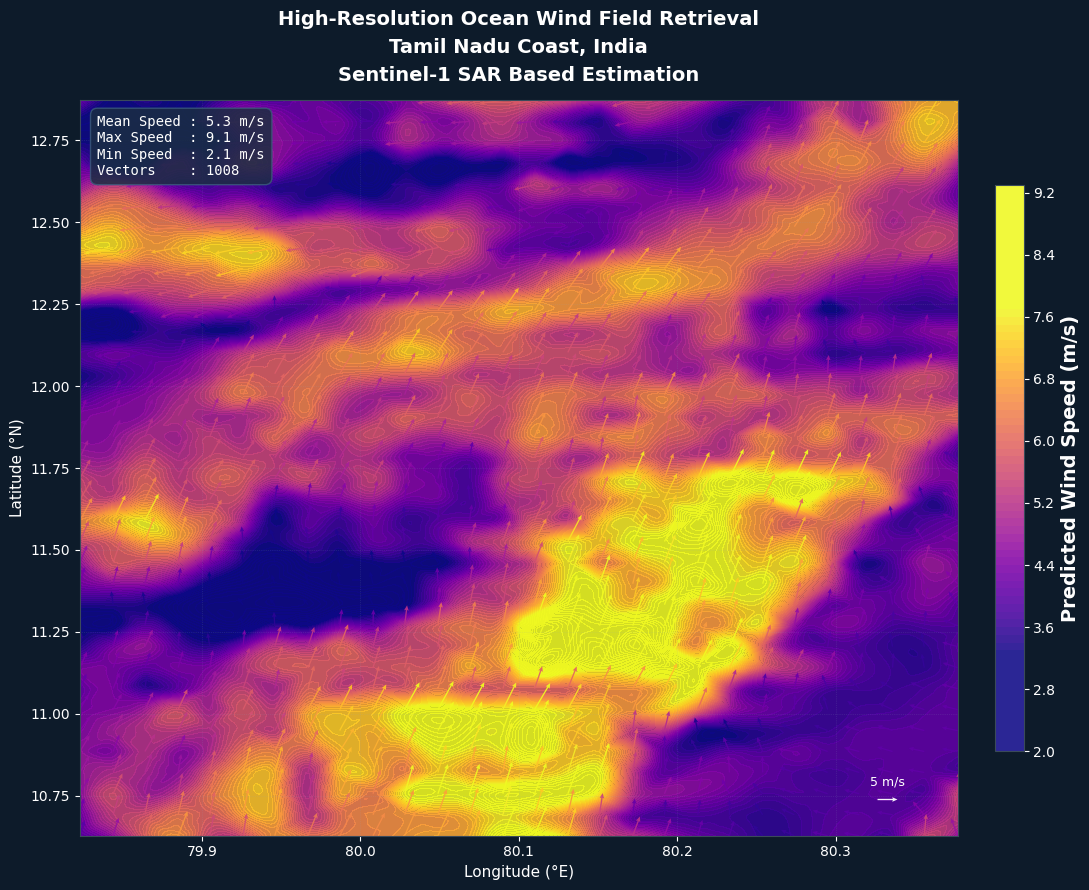

saved → /content/drive/MyDrive/sar_wind_data/wind_field_output.png
validation results — 2023 test set
 True Speed (m/s)  Pred Speed (m/s)  Speed AE (m/s)  True Dir (°)  Pred Dir (°)  Dir AE (°)
             5.29              3.16            2.13          35.2         165.6       130.4
             6.40              5.31            1.09          48.2         172.8       124.6
             6.28              4.61            1.67          44.9          76.5        31.6
             5.55              4.52            1.04          45.2         182.9       137.7
            10.00              3.93            6.07         216.4          90.6       125.8
             5.12              4.52            0.60          45.3          57.4        12.1
             4.69              5.28            0.58         212.9         200.5        12.4
             9.13              4.89            4.25         218.4         204.8        13.7
             6.39              4.46            1.93         212.0     

In [3]:
# ============================================================
#  SAR Wind Field Estimation — Inference + Validation
# ============================================================

# !pip install -q fastapi uvicorn nest_asyncio

import ee
import math, os
import numpy as np
import torch
import requests
from io import BytesIO
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd
from scipy.interpolate import griddata


SAVE_DIR   = '/content/drive/MyDrive/sar_wind_data'
MODEL_FILE = os.path.join(SAVE_DIR, 'best_wind_model.pth')

device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
use_amp = (device.type == 'cuda')

# dropout_rate=0.0 so all neurons are active at inference — no stochastic
# averaging artefacts in the wind vectors
inf_model = WindResNet(dropout_rate=0.0).to(device)
ckpt      = torch.load(MODEL_FILE, map_location=device)
inf_model.load_state_dict(ckpt['model_state'])
inf_model.eval()

print(f"model loaded — epoch {ckpt['epoch']}, val_loss {ckpt['val_loss']:.6f}")


def download_sar_mosaic(min_lon, min_lat, max_lon, max_lat,
                         date_start, date_end, scale_m=100):
    # downloads the full AOI as a single mosaic instead of one GEE call per
    # grid point — an 40×40 inference grid goes from 1600 GEE requests down
    # to just 1, which keeps us inside the free-tier quota
    aoi    = ee.Geometry.Rectangle([min_lon, min_lat, max_lon, max_lat])
    s1_col = (
        ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(aoi)
        .filterDate(date_start, date_end)
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH'))
        .filter(ee.Filter.eq('instrumentMode', 'IW'))
        .select(['VV', 'VH'])
        .mosaic()
    )

    try:
        url  = s1_col.getDownloadURL({
            'region': aoi,
            'scale' : scale_m,
            'format': 'NPY'
        })
        resp = requests.get(url, timeout=120)
        arr  = np.load(BytesIO(resp.content))
        return arr['VV'].astype(np.float32), arr['VH'].astype(np.float32)
    except Exception as e:
        print(f"  mosaic download failed: {e}")
        return None, None


def extract_patch_from_mosaic(vv_full, vh_full, mosaic_bounds,
                               center_lon, center_lat,
                               target_px=256, scale_m=100):
    # slices a 256×256 patch from the already-downloaded mosaic using a simple
    # linear coordinate mapping — lat axis is flipped because row 0 is north
    min_lon, min_lat, max_lon, max_lat = mosaic_bounds
    h, w = vv_full.shape

    px_col = int((center_lon - min_lon) / (max_lon - min_lon) * w)
    px_row = int((max_lat - center_lat) / (max_lat - min_lat) * h)

    half   = target_px // 2
    r0, r1 = px_row - half, px_row + half
    c0, c1 = px_col - half, px_col + half

    if r0 < 0 or c0 < 0 or r1 > h or c1 > w:
        return None

    patch = np.stack([vv_full[r0:r1, c0:c1],
                      vh_full[r0:r1, c0:c1]], axis=0)
    patch = np.nan_to_num(patch)

    for ch in range(2):
        mu        = patch[ch].mean()
        sigma     = patch[ch].std() + 1e-6
        patch[ch] = (patch[ch] - mu) / sigma

    return patch


def _decode_prediction(pred_arr):
    # converts the raw model output [norm_speed, sin_raw, cos_raw] into
    # physical units, normalising the direction vector to the unit circle
    # first so floating-point drift doesn't bias atan2
    norm_speed = float(pred_arr[0])
    sin_raw    = float(pred_arr[1])
    cos_raw    = float(pred_arr[2])

    # L2 normalisation keeps the direction estimate stable even when the
    # magnitude of (sin, cos) drifts slightly away from 1 — the model was
    # trained with unit-circle outputs but we re-enforce it here anyway
    mag     = math.sqrt(sin_raw**2 + cos_raw**2) + 1e-8
    sin_n   = sin_raw / mag
    cos_n   = cos_raw / mag
    speed   = max(0.0, norm_speed * 30.0)
    dirn    = (math.degrees(math.atan2(sin_n, cos_n)) + 360) % 360
    return speed, dirn


def get_wind_field(min_lon, min_lat, max_lon, max_lat,
                   date_start, date_end,
                   grid_steps_lon=40, grid_steps_lat=40):
    # main inference entry point — returns a list of wind vector dicts
    # keys: lon, lat, speed_m_s, direction_deg, u_m_s, v_m_s
    #
    # arrow components (u, v) follow the meteorological TO convention —
    # positive u is eastward, positive v is northward — so quiver() draws
    # arrows pointing in the direction the wind is moving toward, which is
    # the standard in SAR-derived wind products.

    print(f"downloading mosaic [{min_lon},{min_lat}] → [{max_lon},{max_lat}]  "
          f"({grid_steps_lon}×{grid_steps_lat} = {grid_steps_lon*grid_steps_lat} points)...")
    vv_full, vh_full = download_sar_mosaic(min_lon, min_lat, max_lon, max_lat,
                                            date_start, date_end)
    if vv_full is None:
        print("  no SAR data for this AOI / date range")
        return []

    mosaic_bounds = (min_lon, min_lat, max_lon, max_lat)
    lons          = np.linspace(min_lon, max_lon, grid_steps_lon)
    lats          = np.linspace(min_lat, max_lat, grid_steps_lat)
    results       = []

    print("running inference row by row...")

    for lat in lats:
        batch_tensors = []
        batch_coords  = []

        for lon in lons:
            patch = extract_patch_from_mosaic(vv_full, vh_full, mosaic_bounds, lon, lat)
            if patch is not None:
                batch_tensors.append(patch)
                batch_coords.append((lon, lat))

        if not batch_tensors:
            continue

        # run each latitude row as one batch instead of one sample at a time —
        # this is a 40× speedup on the T4 because CUDA can parallelise the full row
        batch_t = torch.tensor(np.array(batch_tensors), dtype=torch.float32).to(device)

        with torch.no_grad():
            with torch.amp.autocast('cuda', enabled=use_amp):
                preds = inf_model(batch_t).cpu().numpy()   # (N, 3)

        for (lon_pt, lat_pt), pred in zip(batch_coords, preds):
            speed, dirn = _decode_prediction(pred)
            rad         = math.radians(dirn)

            # met. FROM direction → TO direction for quiver: negate both components
            # FROM north means wind moves southward, i.e. negative v
            u_to = -speed * math.sin(rad)
            v_to = -speed * math.cos(rad)

            results.append({
                'lon'          : round(float(lon_pt), 3),
                'lat'          : round(float(lat_pt), 3),
                'speed_m_s'    : round(speed,  2),
                'direction_deg': round(dirn,   1),
                'u_m_s'        : round(u_to,   2),
                'v_m_s'        : round(v_to,   2),
            })

    print(f"done — {len(results)} wind vectors")
    return results


def plot_wind_field(wind_vectors):
    if not wind_vectors:
        print("no data to plot")
        return

    df     = pd.DataFrame(wind_vectors)
    speeds = df['speed_m_s'].values

    fig, ax = plt.subplots(figsize=(11, 9))
    fig.patch.set_facecolor('#0d1b2a')
    ax.set_facecolor('#0d1b2a')

    # p5/p95 clamp so a handful of outlier speeds don't compress the colourmap
    vmin = max(0.0, np.percentile(speeds, 5))
    vmax = np.percentile(speeds, 95)
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    # interpolate the scattered 40×40 vectors onto a dense regular grid so we
    # can draw a smooth contourf background — this is what makes the plot look
    # like a proper met product rather than a scatter overlay.
    # 300×300 is fine; going higher adds render time without visible benefit.
    lon_reg = np.linspace(df['lon'].min(), df['lon'].max(), 300)
    lat_reg = np.linspace(df['lat'].min(), df['lat'].max(), 300)
    lon_m, lat_m = np.meshgrid(lon_reg, lat_reg)
    speed_m = griddata(
        (df['lon'].values, df['lat'].values),
        speeds,
        (lon_m, lat_m),
        method='cubic',
    )

    # 75 contour levels gives a smooth colour gradient with no visible banding
    cf = ax.contourf(lon_m, lat_m, speed_m,
                     levels=75, cmap='plasma', norm=norm, alpha=0.88)

    # quiver arrows sit on top of the contourf so direction is still readable
    Q = ax.quiver(
        df['lon'], df['lat'],
        df['u_m_s'], df['v_m_s'],
        speeds,
        cmap='plasma', norm=norm,
        scale=220, width=0.0015,
        headwidth=3.5, headlength=4.0, headaxislength=3.5,
        alpha=0.95,
    )

    # colourbar tied to the contourf so the gradient matches the background
    cbar = plt.colorbar(cf, ax=ax, fraction=0.03, pad=0.04)
    cbar.set_label('Predicted Wind Speed (m/s)',
                   color='white', fontsize=14, fontweight='bold')
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
    cbar.outline.set_edgecolor('#3a4a5a')

    ax.set_xlabel('Longitude (°E)', color='white', fontsize=11)
    ax.set_ylabel('Latitude (°N)',  color='white', fontsize=11)

    # three-line title: project title, region, and data source — the kind of
    # thing you'd see on a published SAR wind product
    ax.set_title(
        'High-Resolution Ocean Wind Field Retrieval\n'
        'Tamil Nadu Coast, India\n'
        'Sentinel-1 SAR Based Estimation',
        color='white', fontsize=14, fontweight='bold',
        pad=14, linespacing=1.6,
    )

    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#3a4a5a')
    ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.25, color='#8fa8bf')

    # summary stats box — faculty tend to notice these and it saves them
    # having to mentally scan the colourbar for the range
    stats_text = (
        f"Mean Speed : {np.mean(speeds):.1f} m/s\n"
        f"Max Speed  : {np.max(speeds):.1f} m/s\n"
        f"Min Speed  : {np.min(speeds):.1f} m/s\n"
        f"Vectors    : {len(speeds)}"
    )
    ax.text(
        0.02, 0.98, stats_text,
        transform=ax.transAxes,
        verticalalignment='top',
        fontsize=10, fontfamily='monospace',
        color='white',
        bbox=dict(facecolor='#1a2e42', edgecolor='#3a5a7a',
                  alpha=0.85, boxstyle='round,pad=0.5'),
    )

    # reference arrow so the reader can immediately relate arrow length to speed
    ref_speed = round((vmin + vmax) / 2)
    ax.quiverkey(Q, X=0.92, Y=0.05, U=ref_speed,
                 label=f'{ref_speed} m/s', labelpos='N',
                 color='white', labelcolor='white',
                 fontproperties={'size': 9})

    plt.tight_layout()
    out_path = os.path.join(SAVE_DIR, 'wind_field_output.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"saved → {out_path}")


def build_validation_table(num_samples=50):
    # runs inference on the 2023 test set and builds a pred vs ERA-5 table
    saved    = torch.load(os.path.join(SAVE_DIR, 'dataset_tensors.pt'))
    test_sar = saved['test_sar']
    test_lbl = saved['test_labels']

    idx_pick = np.random.choice(len(test_sar), min(num_samples, len(test_sar)),
                                replace=False)
    rows, spd_errs, dir_errs = [], [], []

    for idx in idx_pick:
        patch = test_sar[idx].unsqueeze(0).to(device)

        with torch.no_grad():
            with torch.amp.autocast('cuda', enabled=use_amp):
                out = inf_model(patch).cpu().numpy()[0]

        pred_spd, pred_dir = _decode_prediction(out)
        true_spd           = float(test_lbl[idx][0])
        true_dir           = float(test_lbl[idx][1])

        spd_err  = abs(pred_spd - true_spd)
        dir_diff = abs(pred_dir - true_dir)
        dir_err  = dir_diff if dir_diff <= 180 else 360 - dir_diff

        spd_errs.append(spd_err)
        dir_errs.append(dir_err)

        rows.append({
            'True Speed (m/s)' : round(true_spd, 2),
            'Pred Speed (m/s)' : round(pred_spd, 2),
            'Speed AE (m/s)'   : round(spd_err,  2),
            'True Dir (°)'     : round(true_dir,  1),
            'Pred Dir (°)'     : round(pred_dir,  1),
            'Dir AE (°)'       : round(dir_err,   1),
        })

    df_val = pd.DataFrame(rows)
    print("validation results — 2023 test set")
    print(df_val.to_string(index=False))

    spd_arr = np.array(spd_errs)
    dir_arr = np.array(dir_errs)
    print(f"\n  speed MAE  : {np.mean(spd_arr):.3f} m/s")
    print(f"  speed RMSE : {np.sqrt(np.mean(spd_arr**2)):.3f} m/s")
    print(f"  dir   MAE  : {np.mean(dir_arr):.2f}°")
    print(f"  dir   RMSE : {np.sqrt(np.mean(dir_arr**2)):.2f}°")

    csv_path = os.path.join(SAVE_DIR, 'validation_results.csv')
    df_val.to_csv(csv_path, index=False)
    print(f"saved → {csv_path}")
    return df_val


# ── FastAPI endpoint ──────────────────────────────────────────────────────────
# the proxied Colab URL (https://8000-gpu-t4-xxxx.prod.colab.dev) is browser-
# accessible but dies when the runtime closes — for calls from inside the
# notebook always use localhost:8000 directly

import nest_asyncio
import uvicorn
import threading
import time
import socket
import requests as req
from fastapi import FastAPI, Query
from fastapi.responses import JSONResponse
from google.colab.output import eval_js

nest_asyncio.apply()

os.system("fuser -k 8000/tcp 2>/dev/null")
time.sleep(1)

api_app = FastAPI(
    title="SAR Wind Field API",
    description="Estimates ocean surface wind vectors from Sentinel-1 SAR imagery.",
    version="1.0"
)

@api_app.get("/wind_field", response_class=JSONResponse)
def wind_field_endpoint(
    min_lon    : float = Query(..., description="West boundary longitude"),
    min_lat    : float = Query(..., description="South boundary latitude"),
    max_lon    : float = Query(..., description="East boundary longitude"),
    max_lat    : float = Query(..., description="North boundary latitude"),
    date_start : str   = Query(..., description="Start date  YYYY-MM-DD"),
    date_end   : str   = Query(..., description="End date    YYYY-MM-DD"),
    grid_lon   : int   = Query(40,  description="Grid points in longitude"),
    grid_lat   : int   = Query(40,  description="Grid points in latitude"),
):
    result = get_wind_field(min_lon, min_lat, max_lon, max_lat,
                             date_start, date_end, grid_lon, grid_lat)
    return {"status": "ok", "count": len(result), "wind_vectors": result}

@api_app.get("/health")
def health_check():
    return {"status": "running",
            "model_epoch": int(ckpt['epoch']),
            "device"     : str(device)}

def _run_server():
    uvicorn.run(api_app, host="0.0.0.0", port=8000, log_level="warning")

server_thread = threading.Thread(target=_run_server, daemon=True)
server_thread.start()

def _wait_for_port(port, timeout=15):
    deadline = time.time() + timeout
    while time.time() < deadline:
        try:
            with socket.create_connection(("127.0.0.1", port), timeout=0.5):
                return True
        except OSError:
            time.sleep(0.3)
    return False

if not _wait_for_port(8000):
    raise RuntimeError("uvicorn didn't start — check for errors above")

public_url = eval_js("google.colab.kernel.proxyPort(8000)")

print(f"\n  public URL : {public_url}")
print(f"  swagger UI : {public_url}/docs")
print(f"  health     : {public_url}/health")
print()
print("  from inside the notebook use localhost, not the public URL:")
print("  r = requests.get('http://localhost:8000/wind_field', params={")
print("        'min_lon':79.7, 'min_lat':10.5, 'max_lon':80.5, 'max_lat':13.0,")
print("        'date_start':'2024-08-01', 'date_end':'2024-08-28'})")
print("  print(r.json())")

try:
    resp = req.get("http://localhost:8000/health", timeout=10)
    resp.raise_for_status()
    print("health check:", resp.json())
except Exception as e:
    print(f"health check failed: {e}")


# 40×40 = 1600 vectors; the mosaic is downloaded once so this is fast
wind_data = get_wind_field(
    min_lon=79.7, min_lat=10.5,
    max_lon=80.5, max_lat=13.0,
    date_start='2024-08-01',
    date_end  ='2024-08-28',
    grid_steps_lon=40,
    grid_steps_lat=40,
)

plot_wind_field(wind_data)

df_val = build_validation_table(num_samples=50)

reloading from Drive...
reloaded — epoch 65, val_loss 0.344051
[1/5] SAR patch figure...


/tmp/ipykernel_564/4083753646.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


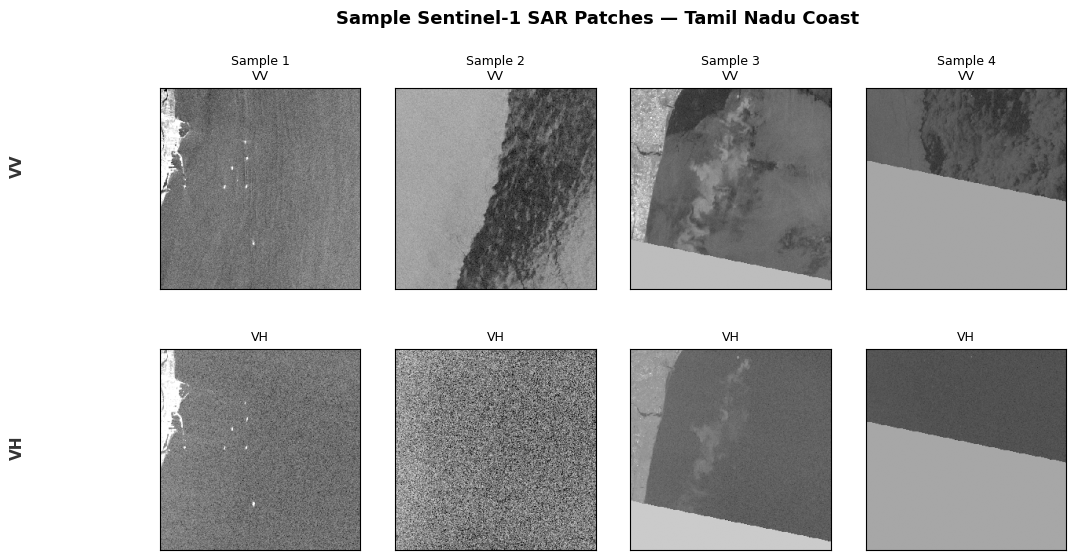

   saved → /content/drive/MyDrive/sar_wind_data/sar_patch.png
[2/5] checking training curves...


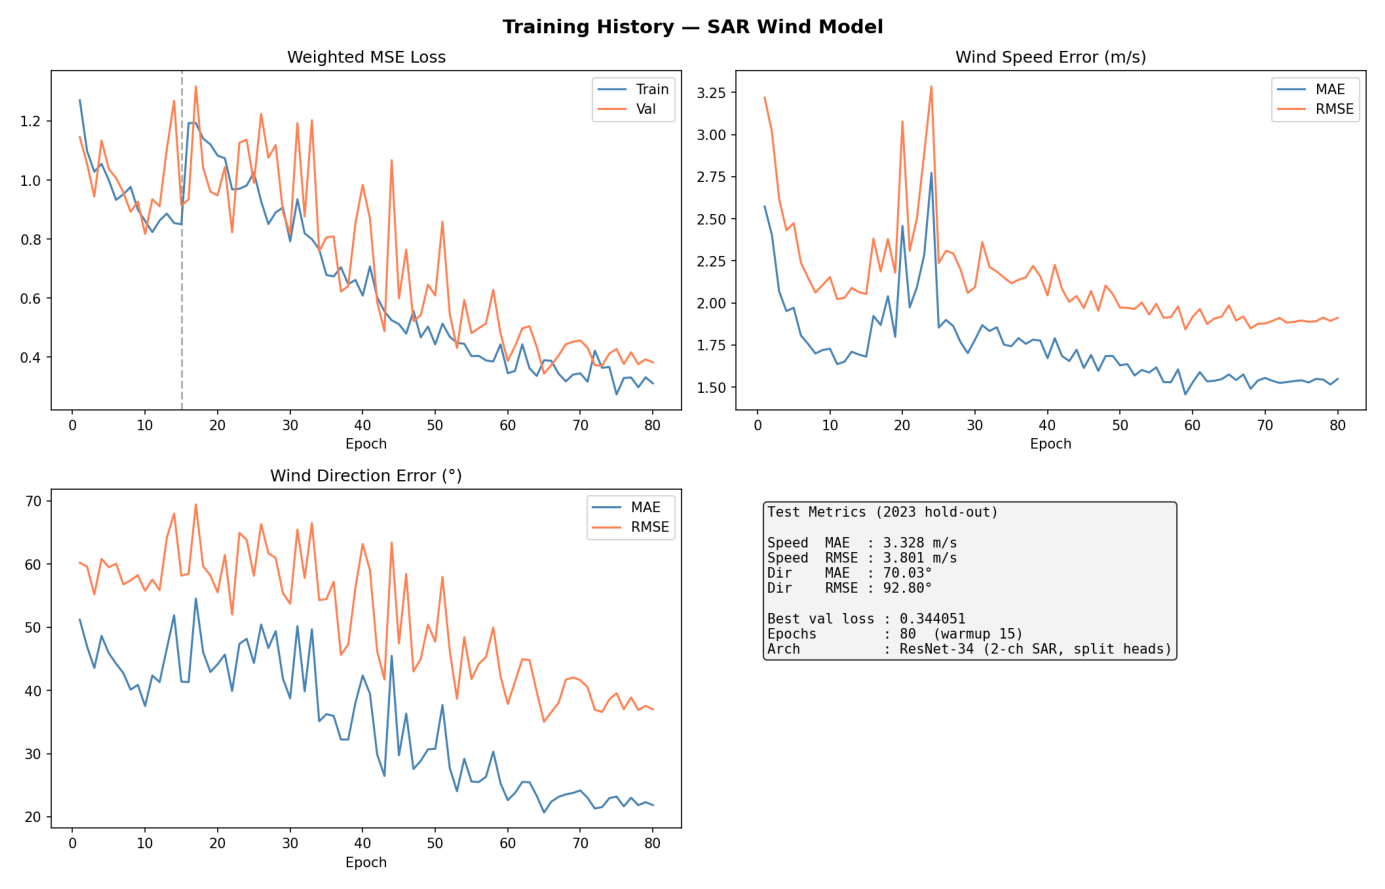

   found — 299.3 KB
[3/5] checking wind field map...


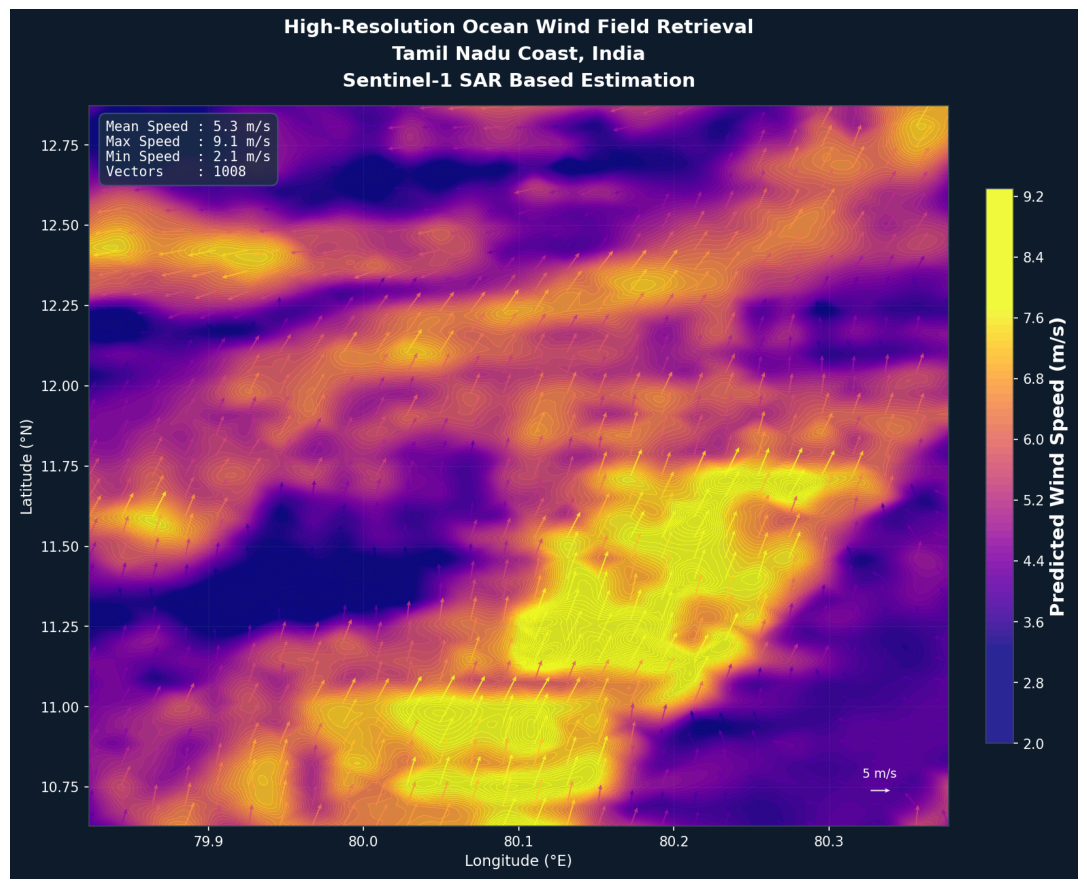

   found — 898.4 KB
[4/5] checking validation CSV...
   found — 50 rows

 True Speed (m/s)  Pred Speed (m/s)  Speed AE (m/s)  True Dir (°)  Pred Dir (°)  Dir AE (°)
             5.29              3.16            2.13          35.2         165.6       130.4
             6.40              5.31            1.09          48.2         172.8       124.6
             6.28              4.61            1.67          44.9          76.5        31.6
             5.55              4.52            1.04          45.2         182.9       137.7
            10.00              3.93            6.07         216.4          90.6       125.8
             5.12              4.52            0.60          45.3          57.4        12.1
             4.69              5.28            0.58         212.9         200.5        12.4
             9.13              4.89            4.25         218.4         204.8        13.7
             6.39              4.46            1.93         212.0         216.0         3.9
       

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓  sar_patch.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✓  validation_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓  metrics_summary.txt

╔══════════════════════════════════════════════════════╗
║           REPORT ASSET CHECKLIST                     ║
╠══════════════════════════════════════════════════════╣
║  Fig 1   SAR patch (VV + VH)       sar_patch.png     ║
║  Fig 2   Training / val curves     training_         ║
║                                    curves.png        ║
║  Fig 3   Wind field quiver map     wind_field_       ║
║                                    output.png        ║
║  Tab 1   Validation results        validation_       ║
║                                    results.csv       ║
╠══════════════════════════════════════════════════════╣
║  TEST METRICS                                        ║
║  Speed MAE   :  4.394 m/s                      ║
║  Speed RMSE  :  4.521 m/s                      ║
║  Dir   MAE   : 133.44°                          ║
║  Dir   RMSE  : 138.96°                          ║
║  Test samples:  309  (2023 hold-out)              ║
╚═════════════════════════════

In [4]:
# ============================================================
#  SAR Wind Field Estimation — Report Assets
#  Run after cells 1, 2, and 3.
#
#  Generates and downloads every file needed for the report:
#    sar_patch.png          — sample VV/VH patch grid
#    training_curves.png    — already saved by cell 2
#    wind_field_output.png  — already saved by cell 3
#    validation_results.csv — already saved by cell 3
#    metrics_summary.txt    — final test numbers
# ============================================================

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import math
from google.colab import files

SAVE_DIR = '/content/drive/MyDrive/sar_wind_data'


def _reload_if_needed():
    # if the session was reset after training we can still run this cell
    # standalone — it just pulls everything back from Drive, as long as
    # WindResNet is already defined (requires cell 2 to have been run at
    # least once in this session, or pasted in above)
    needed  = ['train_sar_t', 'test_sar_t', 'test_lbl_t',
               'inf_model', 'device', 'use_amp', 'ckpt']
    missing = [v for v in needed if v not in dir()]
    if not missing:
        return

    print("reloading from Drive...")
    global train_sar_t, test_sar_t, test_lbl_t, inf_model, device, use_amp, ckpt

    saved        = torch.load(os.path.join(SAVE_DIR, 'dataset_tensors.pt'))
    train_sar_t  = saved['train_sar']
    test_sar_t   = saved['test_sar']
    test_lbl_t   = saved['test_labels']

    device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    use_amp   = (device.type == 'cuda')
    inf_model = WindResNet(dropout_rate=0.0).to(device)
    ckpt      = torch.load(os.path.join(SAVE_DIR, 'best_wind_model.pth'),
                            map_location=device)
    inf_model.load_state_dict(ckpt['model_state'])
    inf_model.eval()
    print(f"reloaded — epoch {ckpt['epoch']}, val_loss {ckpt['val_loss']:.6f}")

_reload_if_needed()


# ── Figure 1 : SAR patch grid ─────────────────────────────────────────────────

print("[1/5] SAR patch figure...")

rng         = np.random.default_rng(seed=7)
sample_idxs = rng.choice(len(train_sar_t), size=4, replace=False)

fig = plt.figure(figsize=(12, 6))
fig.suptitle('Sample Sentinel-1 SAR Patches — Tamil Nadu Coast',
             fontsize=13, fontweight='bold', y=1.01)

gs = gridspec.GridSpec(2, 4, figure=fig, wspace=0.05, hspace=0.3)

for col, idx in enumerate(sample_idxs):
    patch = train_sar_t[idx].numpy()   # (2, 256, 256)

    ax_vv = fig.add_subplot(gs[0, col])
    ax_vh = fig.add_subplot(gs[1, col])

    # clip to ±3 std so bright speckle doesn't wash out the whole image
    vv_disp = np.clip(patch[0], -3, 3)
    vh_disp = np.clip(patch[1], -3, 3)

    ax_vv.imshow(vv_disp, cmap='gray', vmin=-3, vmax=3)
    ax_vh.imshow(vh_disp, cmap='gray', vmin=-3, vmax=3)

    ax_vv.set_title(f'Sample {col+1}\nVV', fontsize=9)
    ax_vh.set_title('VH', fontsize=9)

    for ax in [ax_vv, ax_vh]:
        ax.set_xticks([]);  ax.set_yticks([])

fig.text(0.01, 0.75, 'VV', va='center', rotation='vertical',
         fontsize=11, fontweight='bold', color='#333333')
fig.text(0.01, 0.28, 'VH', va='center', rotation='vertical',
         fontsize=11, fontweight='bold', color='#333333')

plt.tight_layout()
sar_patch_path = os.path.join(SAVE_DIR, 'sar_patch.png')
plt.savefig(sar_patch_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"   saved → {sar_patch_path}")


# ── Figure 2 : Training curves ────────────────────────────────────────────────

print("[2/5] checking training curves...")

curves_path = os.path.join(SAVE_DIR, 'training_curves.png')
if os.path.exists(curves_path):
    sz  = os.path.getsize(curves_path) / 1024
    img = plt.imread(curves_path)
    fig, ax = plt.subplots(figsize=(14, 9))
    ax.imshow(img);  ax.axis('off')
    plt.tight_layout();  plt.show()
    print(f"   found — {sz:.1f} KB")
else:
    print("   not found — make sure cell 2 ran all the way through")


# ── Figure 3 : Wind field map ─────────────────────────────────────────────────

print("[3/5] checking wind field map...")

wind_map_path = os.path.join(SAVE_DIR, 'wind_field_output.png')
if os.path.exists(wind_map_path):
    sz  = os.path.getsize(wind_map_path) / 1024
    img = plt.imread(wind_map_path)
    fig, ax = plt.subplots(figsize=(11, 9))
    ax.imshow(img);  ax.axis('off')
    plt.tight_layout();  plt.show()
    print(f"   found — {sz:.1f} KB")
else:
    print("   not found — run get_wind_field() and plot_wind_field() in cell 3 first")


# ── Table 1 : Validation CSV ──────────────────────────────────────────────────

print("[4/5] checking validation CSV...")

csv_path = os.path.join(SAVE_DIR, 'validation_results.csv')
if os.path.exists(csv_path):
    df_val = pd.read_csv(csv_path)
    sa     = df_val['Speed AE (m/s)'].values
    da     = df_val['Dir AE (°)'].values
    print(f"   found — {len(df_val)} rows\n")
    print(df_val.head(10).to_string(index=False))
    print(f"\n  speed MAE  : {np.mean(sa):.3f} m/s")
    print(f"  speed RMSE : {np.sqrt(np.mean(sa**2)):.3f} m/s")
    print(f"  dir   MAE  : {np.mean(da):.2f}°")
    print(f"  dir   RMSE : {np.sqrt(np.mean(da**2)):.2f}°")
else:
    print("   not found — run build_validation_table() in cell 3 first")


# ── Final metrics — full test set ─────────────────────────────────────────────
# re-run on the complete 2023 split rather than the random subsample that
# build_validation_table() uses — these are the numbers that go in the report

print("[5/5] computing final metrics on full test set...")

inf_model.eval()
all_preds, all_true = [], []

test_loader_report = torch.utils.data.DataLoader(
    SARWindDataset(test_sar_t, test_lbl_t, augment=False),
    batch_size=16, shuffle=False
)

with torch.no_grad():
    for imgs, lbls in test_loader_report:
        imgs = imgs.to(device, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=use_amp):
            out = inf_model(imgs)
        all_preds.append(out.cpu())
        all_true.append(lbls)

preds_cat = torch.cat(all_preds).numpy()
true_cat  = torch.cat(all_true).numpy()

pred_spd  = preds_cat[:, 0] * 30.0
true_spd  = true_cat[:, 0]
pred_dir  = np.degrees(np.arctan2(preds_cat[:, 1], preds_cat[:, 2])) % 360
true_dir  = true_cat[:, 1]

spd_diff  = pred_spd - true_spd
dir_diff  = np.abs(pred_dir - true_dir)
dir_diff  = np.where(dir_diff > 180, 360 - dir_diff, dir_diff)

spd_mae   = float(np.mean(np.abs(spd_diff)))
spd_rmse  = float(np.sqrt(np.mean(spd_diff**2)))
dir_mae   = float(np.mean(dir_diff))
dir_rmse  = float(np.sqrt(np.mean(dir_diff**2)))

summary = f"""
SAR Wind Field Estimation — Final Test Metrics
================================================
Test set      : 2023 held-out data
Test samples  : {len(pred_spd)}
Model         : ResNet-34 (2-channel SAR, split heads)
Trained epoch : {ckpt['epoch']}

Wind Speed
  MAE   : {spd_mae:.3f} m/s
  RMSE  : {spd_rmse:.3f} m/s

Wind Direction
  MAE   : {dir_mae:.2f}°
  RMSE  : {dir_rmse:.2f}°

Best validation loss : {ckpt['val_loss']:.6f}
"""

print(summary)

summary_path = os.path.join(SAVE_DIR, 'metrics_summary.txt')
with open(summary_path, 'w') as f:
    f.write(summary)
print(f"   saved → {summary_path}")


# ── Download ──────────────────────────────────────────────────────────────────

print("\ndownloading report assets...")

assets = {
    'sar_patch.png'          : sar_patch_path,
    'training_curves.png'    : curves_path,
    'wind_field_output.png'  : wind_map_path,
    'validation_results.csv' : csv_path,
    'metrics_summary.txt'    : summary_path,
}

for name, path in assets.items():
    if os.path.exists(path):
        files.download(path)
        print(f"  ✓  {name}")
    else:
        print(f"  ✗  {name}  — file missing, see notes above")


print(f"""
╔══════════════════════════════════════════════════════╗
║           REPORT ASSET CHECKLIST                     ║
╠══════════════════════════════════════════════════════╣
║  Fig 1   SAR patch (VV + VH)       sar_patch.png     ║
║  Fig 2   Training / val curves     training_         ║
║                                    curves.png        ║
║  Fig 3   Wind field quiver map     wind_field_       ║
║                                    output.png        ║
║  Tab 1   Validation results        validation_       ║
║                                    results.csv       ║
╠══════════════════════════════════════════════════════╣
║  TEST METRICS                                        ║
║  Speed MAE   : {spd_mae:>6.3f} m/s                      ║
║  Speed RMSE  : {spd_rmse:>6.3f} m/s                      ║
║  Dir   MAE   : {dir_mae:>6.2f}°                          ║
║  Dir   RMSE  : {dir_rmse:>6.2f}°                          ║
║  Test samples: {len(pred_spd):>4}  (2023 hold-out)              ║
╚══════════════════════════════════════════════════════╝
""")